# Censor Augmentation

`censor_augmentation` clips each sample toward a random empirical quantile of the
series. A Bernoulli draw chooses the direction: with probability `bernoulli_p`
the value is **lower-censored** (`max` with the threshold), otherwise
**upper-censored** (`min`). This mimics sensor saturation and floor/ceiling effects
while keeping length unchanged.

| Parameter | Default | Role |
| --- | --- | --- |
| `upper_quantile` | 0.65 | Upper end of the per-step quantile draw |
| `lower_quantile` | 0.35 | Lower end of the per-step quantile draw |
| `bernoulli_p` | 0.8 | Probability of lower-censoring (clip from below) |
| `rng` / `seed` | `seed=42` | Reproducibility |

A tighter `[lower, upper]` band clips more aggressively. `bernoulli_p=1` always
raises troughs; `bernoulli_p=0` always cuts peaks.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import censor_augmentation

## Default effect on synthetic and real series


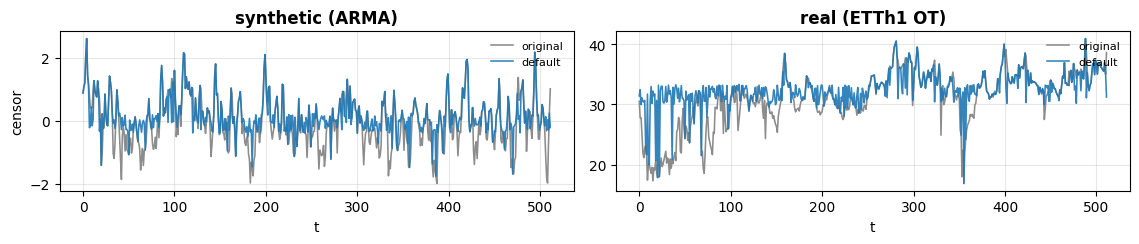

synth unique-ish range orig/aug -1.994 2.61 | -1.769 2.61


In [2]:
aug_s = censor_augmentation(synth, rng=np.random.RandomState(1))
aug_r = censor_augmentation(real, rng=np.random.RandomState(1))
overlay_pair(
    [synth, real],
    [[("default", aug_s)], [("default", aug_r)]],
    titles=["censor"],
)
plt.show()
print(
    "synth unique-ish range orig/aug",
    synth.min().round(3),
    synth.max().round(3),
    "|",
    aug_s.min().round(3),
    aug_s.max().round(3),
)

## Parameter effect

Compare a mild quantile window, a harsh window, always-lower vs always-upper clipping.


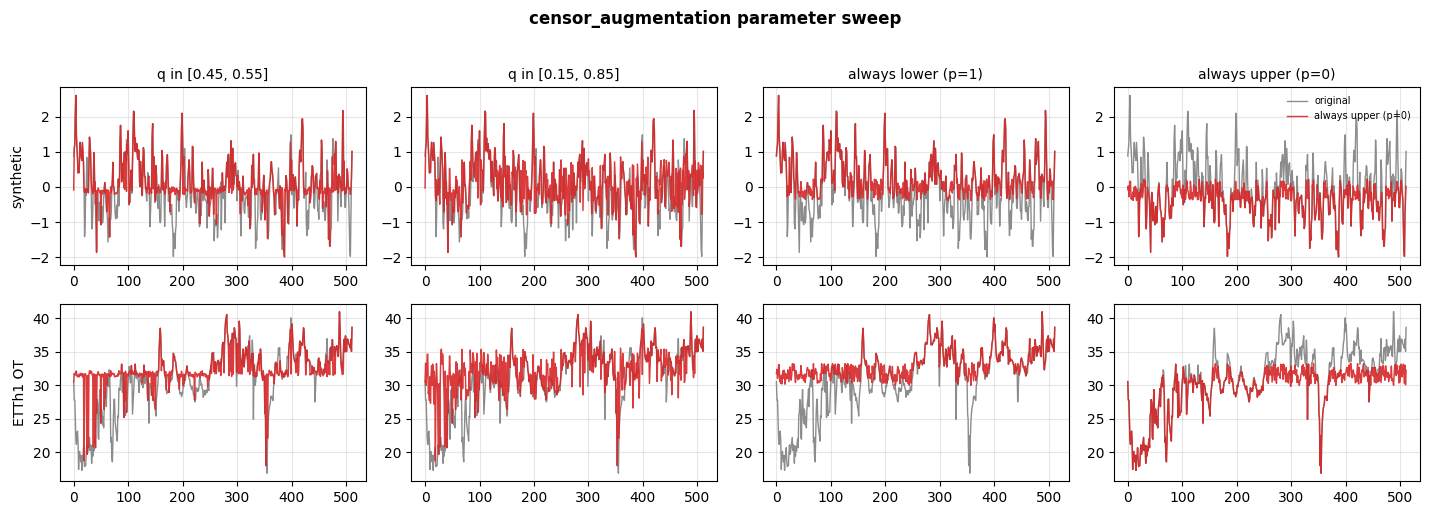

In [3]:
makers = [
    (
        "q in [0.45, 0.55]",
        lambda x: censor_augmentation(
            x, lower_quantile=0.45, upper_quantile=0.55, rng=np.random.RandomState(3)
        ),
    ),
    (
        "q in [0.15, 0.85]",
        lambda x: censor_augmentation(
            x, lower_quantile=0.15, upper_quantile=0.85, rng=np.random.RandomState(3)
        ),
    ),
    (
        "always lower (p=1)",
        lambda x: censor_augmentation(x, bernoulli_p=1.0, rng=np.random.RandomState(3)),
    ),
    (
        "always upper (p=0)",
        lambda x: censor_augmentation(x, bernoulli_p=0.0, rng=np.random.RandomState(3)),
    ),
]
sweep_grid(
    [synth, real],
    ["synthetic", "ETTh1 OT"],
    makers,
    "censor_augmentation parameter sweep",
)
plt.show()